In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/survey lung cancer.csv")

In [ ]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [ ]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates().sum()

,0
GENDER,MMFMFFMFFMFMFMMFMMFFFFFMMMFMFMFMMFMFMFMMMMFMFM...
AGE,17363
SMOKING,426
YELLOW_FINGERS,435
ANXIETY,413
PEER_PRESSURE,416
CHRONIC DISEASE,420
FATIGUE,459
ALLERGY,427
WHEEZING,427


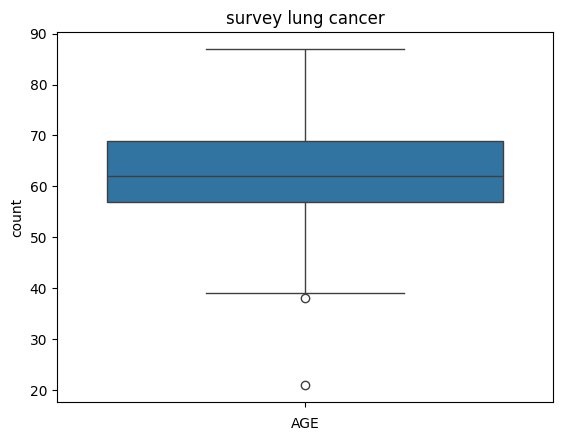

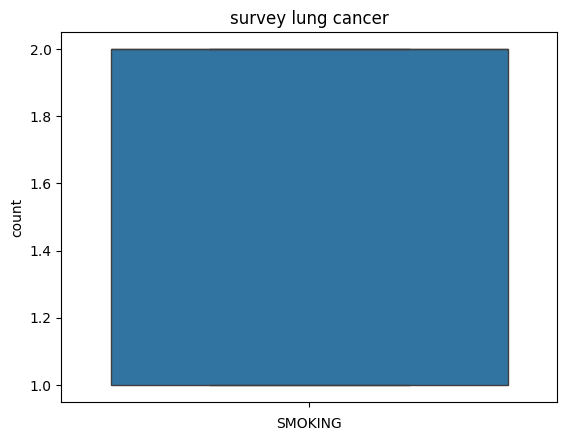

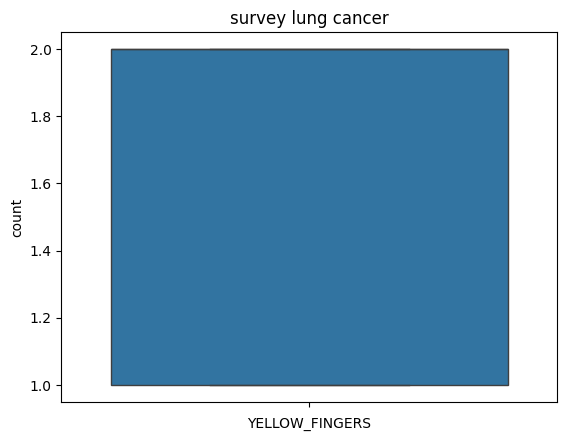

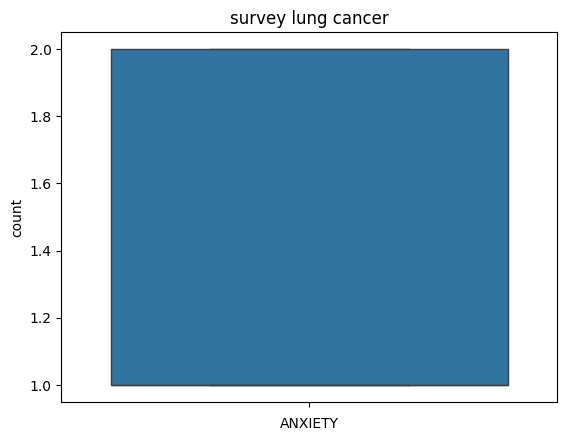

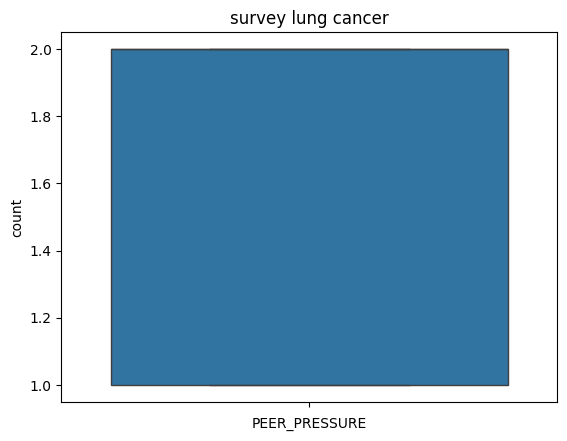

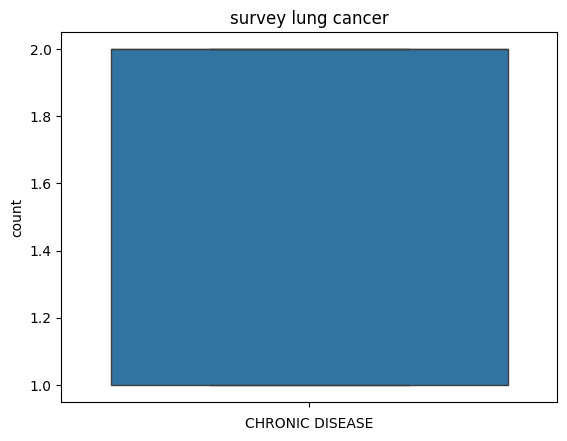

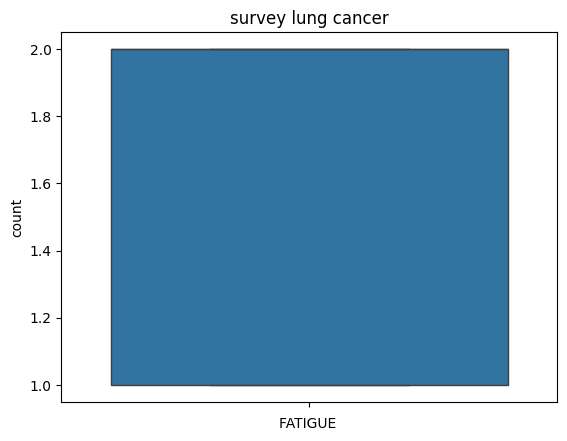

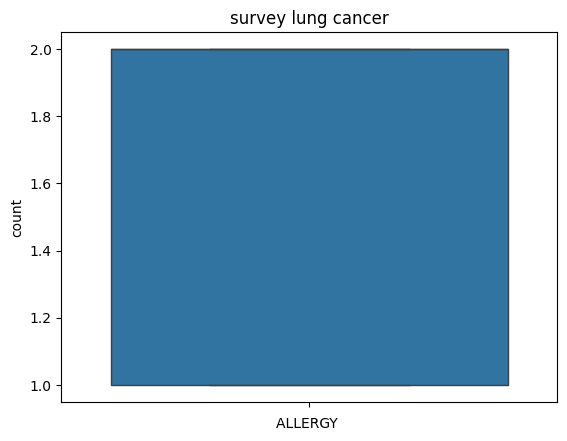

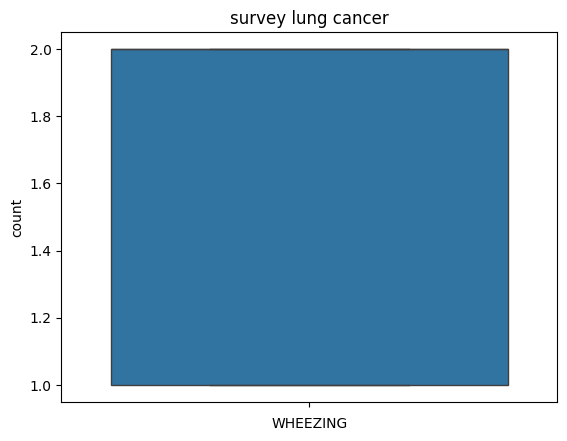

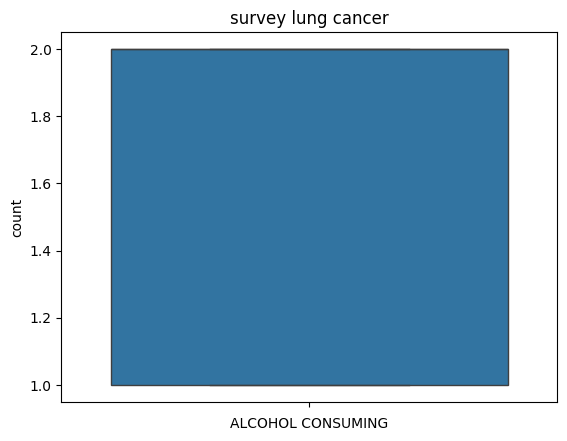

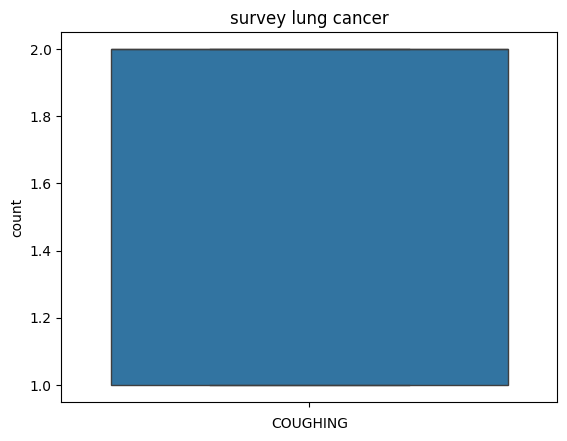

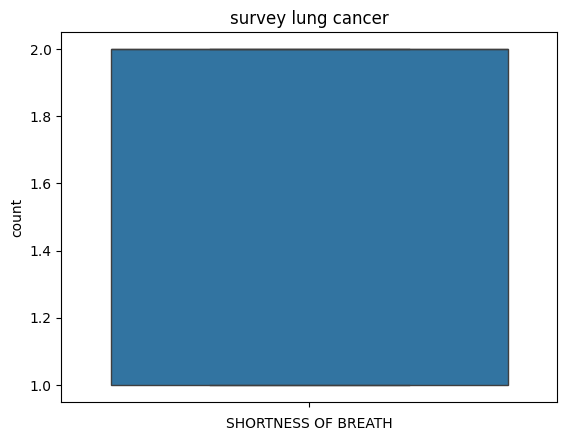

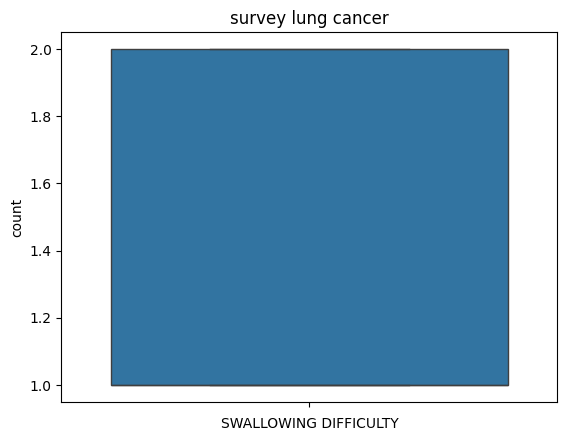

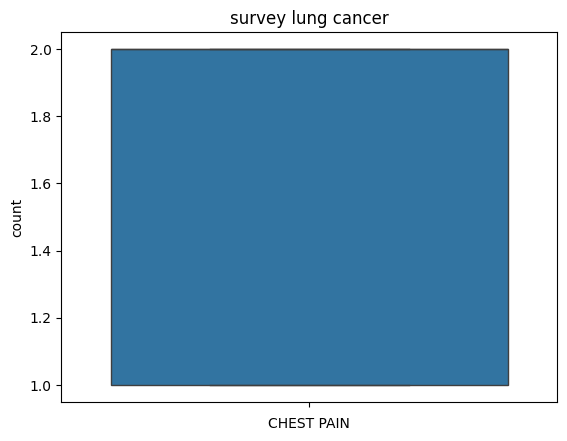

In [ ]:
for i in df.columns:
  if df[i].dtypes!="object":
    sns.boxplot(df[i])
    plt.title("survey lung cancer")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer

In [ ]:
pt=PowerTransformer(method="yeo-johnson")
df['AGE']=pt.fit_transform(df[['AGE']])
df

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,0.766040,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,1.444809,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,-0.492344,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,-0.005122,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,-0.005122,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,-0.843343,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,0.899193,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,-0.610729,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,0.503676,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


<Axes: ylabel='AGE'>

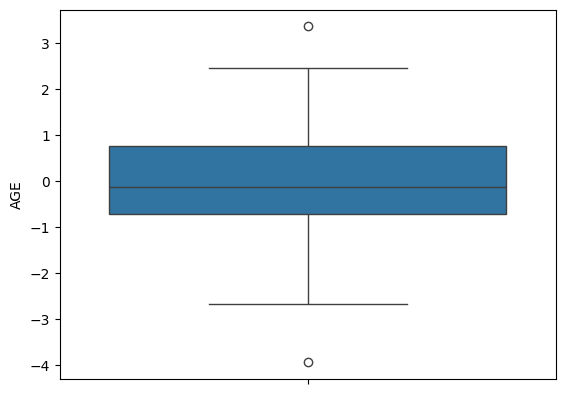

In [ ]:
sns.boxplot(df['AGE'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])

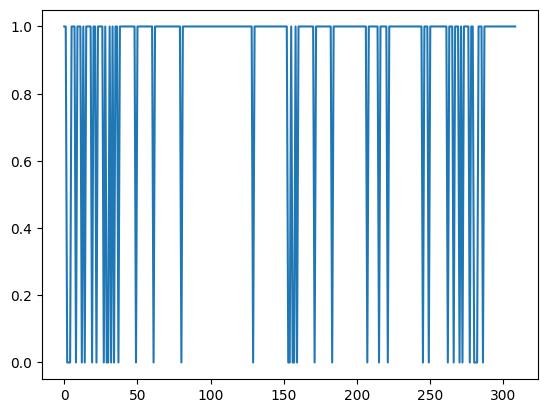

<Axes: >

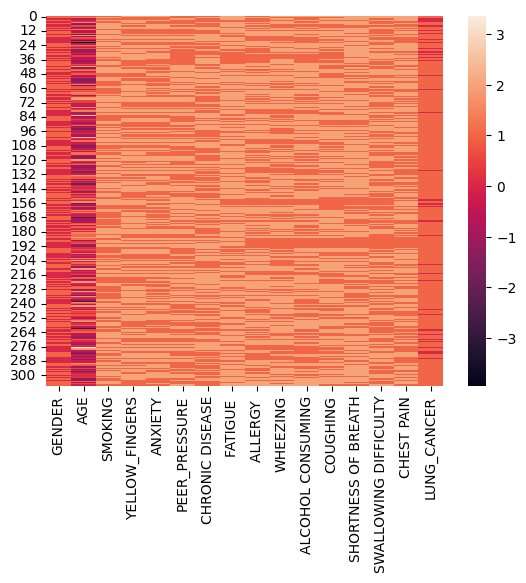

In [ ]:
sns.heatmap(df)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.iloc[:,:-1]
y=df['LUNG_CANCER']


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()
dc.fit(x_train,y_train)
y_pred=dc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Accuracy score",accuracy_score(y_test,y_pred)*100)

Accuracy score 96.7741935483871


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz
from sklearn import tree

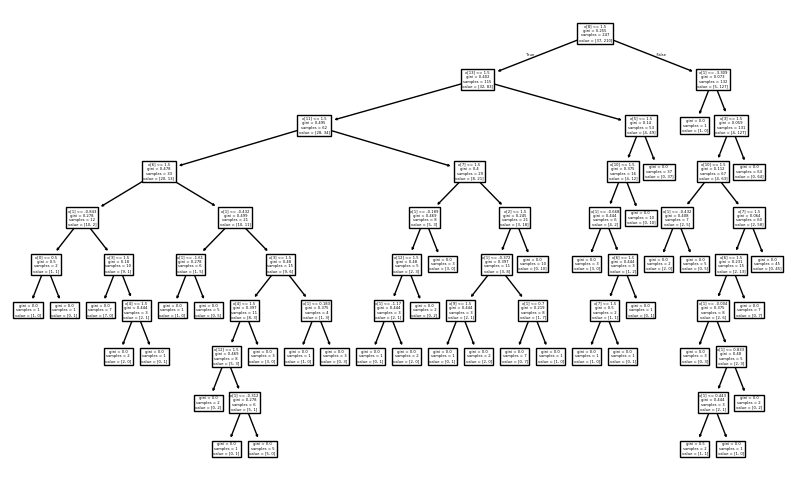

In [ ]:
from matplotlib import pyplot as plt
from sklearn import tree
fig=plt.figure(figsize=(10,6))
tree.plot_tree(dc,max_depth=15)
plt.show()